## Importing Pandas , Numpy, Matplotlib,Seaborn and Warning Library .


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('data/stud.csv')

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

## Data Check to perform

* check Missing values
* Check Duplicates
* Check data types
* check the number of unique values of each them 
* check stastics of data set
* check various categories present in the different categorical column

In [5]:
# Checking for missing values
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

There are no missing values in data set

In [6]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

There are no duplicates values in the data set

In [7]:
# check data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [8]:
## checking the number of unique values in each column
df.nunique()


## for race and parental columns we have to do one hot encoding

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [9]:
# check statistical summary of the data
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## Insight 

* from above description of numerical data , all mean are very close to eeach other - between 66 and 68.05
* All standard deviation lie between 14.6 to 15.19


## Exploring Data

In [10]:
print("Categories in 'gender ' variable :  ",end="")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variable :  ",end="")
print(df['race/ethnicity'].unique())

Categories in 'gender ' variable :  <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race/ethnicity' variable :  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str


In [11]:
print("Categories in 'parental level of education ' variable :  ",end="")
print(df['parental level of education'].unique())

Categories in 'parental level of education ' variable :  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str


In [12]:
print("Categories in 'lunch  ' variable :  ",end="")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable :  ",end="")
print(df['test preparation course'].unique())

Categories in 'lunch  ' variable :  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable :  <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [13]:
# Define numeric and categorical columns

numeric_features = [feature for feature in df.columns if df[feature].dtype != 'str']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']

# peint columns
print("we have {} numeric features : {}".format(len(numeric_features),numeric_features))
print("\nwe have {} categorical  features : {}".format(len(categorical_features),categorical_features))

we have 3 numeric features : ['math score', 'reading score', 'writing score']

we have 5 categorical  features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


## Adding columns for total Score and Average 

In [14]:
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [15]:
df['Total Score']=df['math score']+df['reading score']+df['writing score']
df['Average']=df['Total Score']/3


In [16]:
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


In [17]:
reading_full=df[df['reading score'] == 100]['Average'].count()
writing_full=df[df['writing score'] == 100]['Average'].count()
math_full=df[df['math score'] == 100]['Average'].count()

print(f"Number of students who scored full marks in reading : {reading_full}")
print(f"Number of students who scored full marks in writing : {writing_full}")
print(f"Number of students who scored full marks in math : {math_full}")


Number of students who scored full marks in reading : 17


Number of students who scored full marks in writing : 14
Number of students who scored full marks in math : 7


In [18]:
reading_less_20=df[df['reading score']<= 20]['Average'].count()
writing_less_20=df[df['writing score']<= 20]['Average'].count()
math_less_20=df[df['math score']<= 20]['Average'].count()

print(f'Number of student with less than 20 marks in math : {math_less_20}')
print(f'Number of student with less than 20 marks in reading : {reading_less_20}')
print(f'Number of student with less than 20 marks in writing : {writing_less_20}')

Number of student with less than 20 marks in math : 4
Number of student with less than 20 marks in reading : 1
Number of student with less than 20 marks in writing : 3


## Exploring data (Visulization )

* Visulize average score distribution to make some conclusion 
    * Histogram
    * KDE

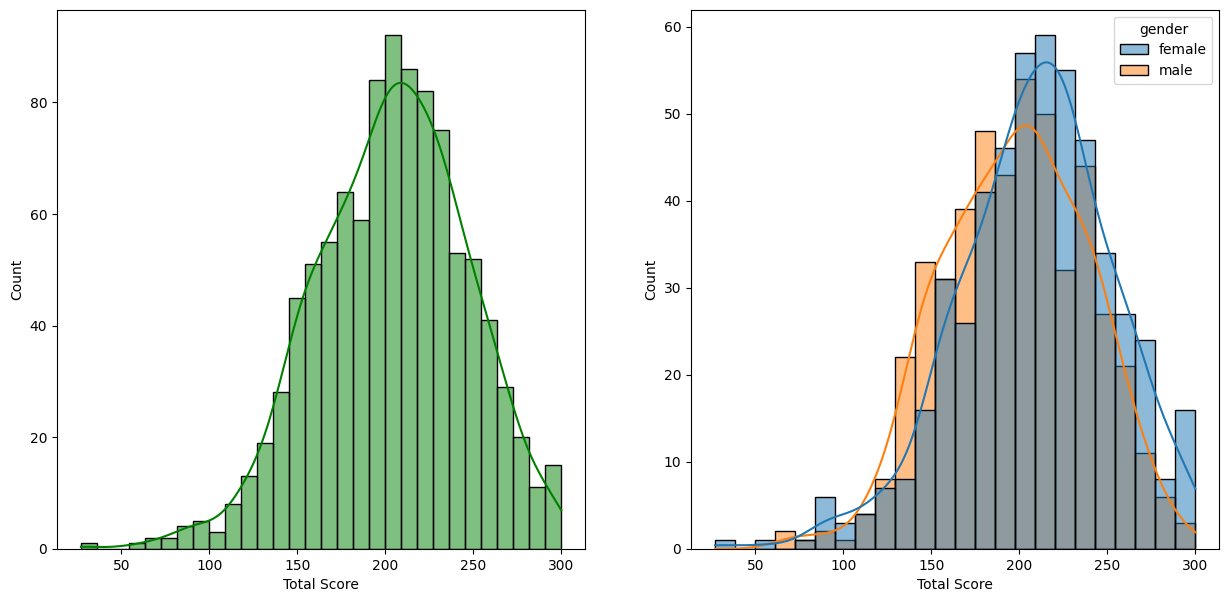

In [19]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='Total Score',bins = 30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df, x='Total Score',kde=True,hue = 'gender')
plt.show()

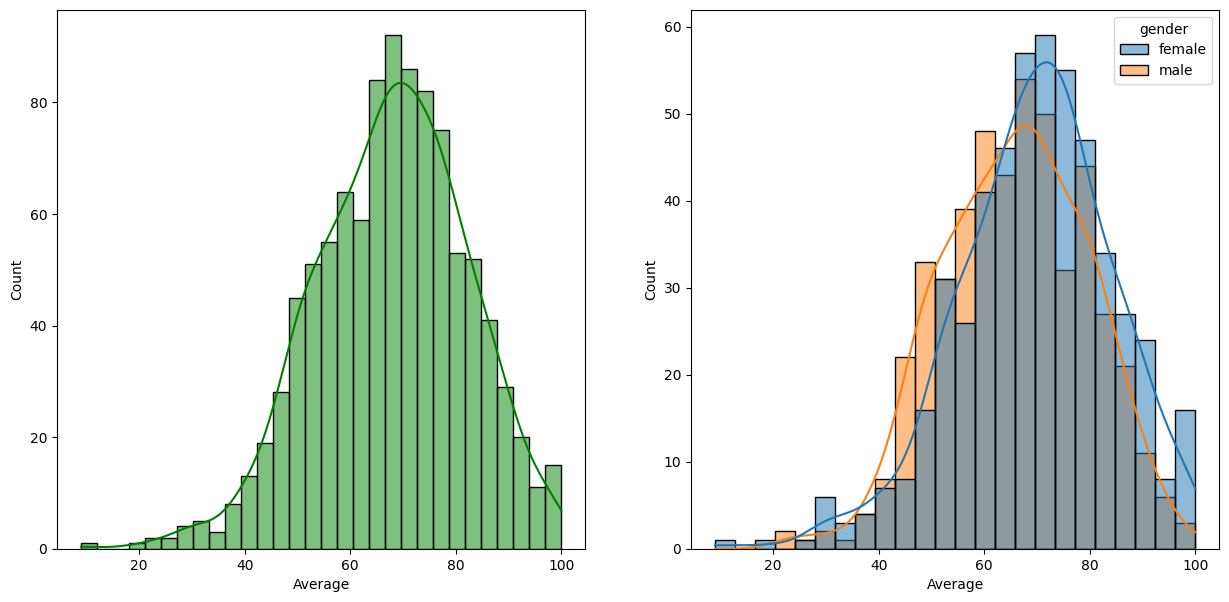

In [20]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='Average',bins = 30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df, x='Average',kde=True,hue = 'gender')
plt.show()



# Insights
* Female are performing better then male

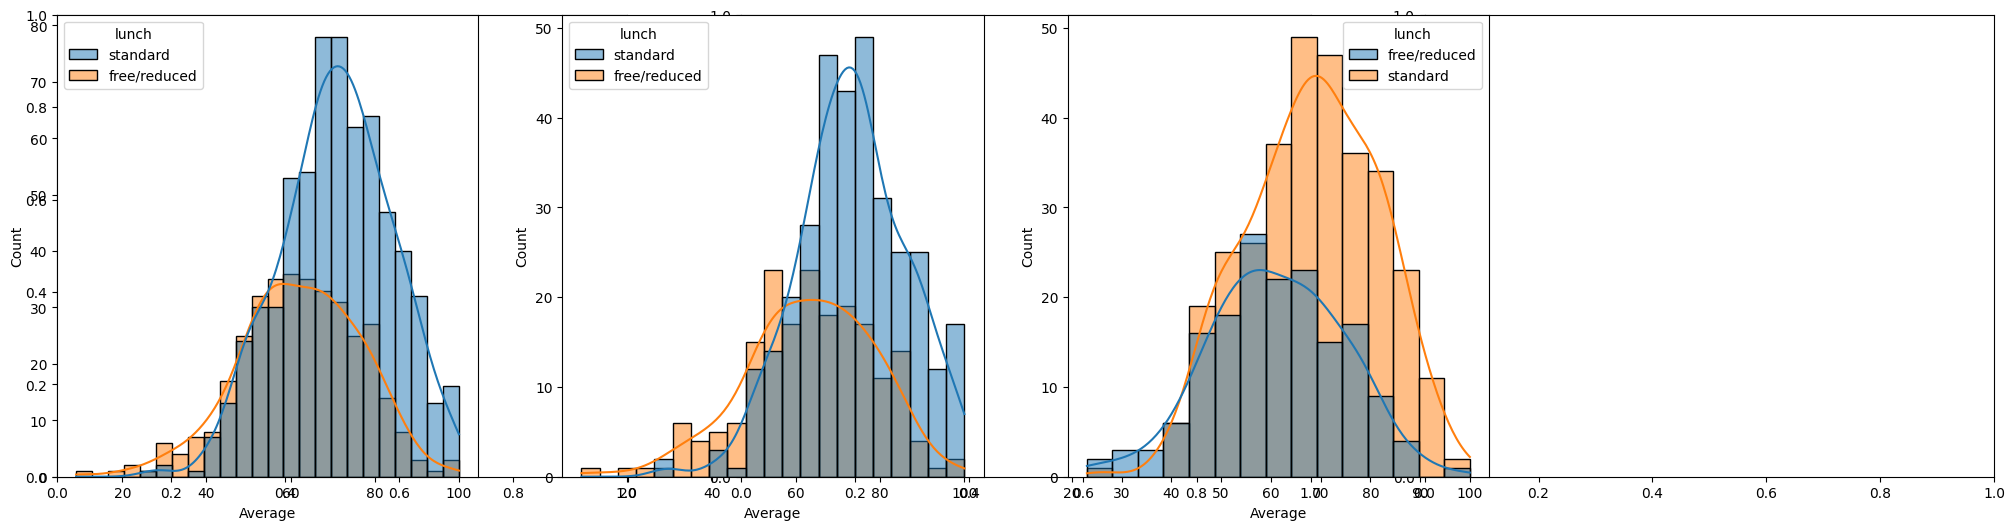

In [21]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='Average',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender== 'female'],x='Average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender== 'male'],x='Average',kde=True,hue='lunch')
plt.show()

* standard lunch helps perform in exam

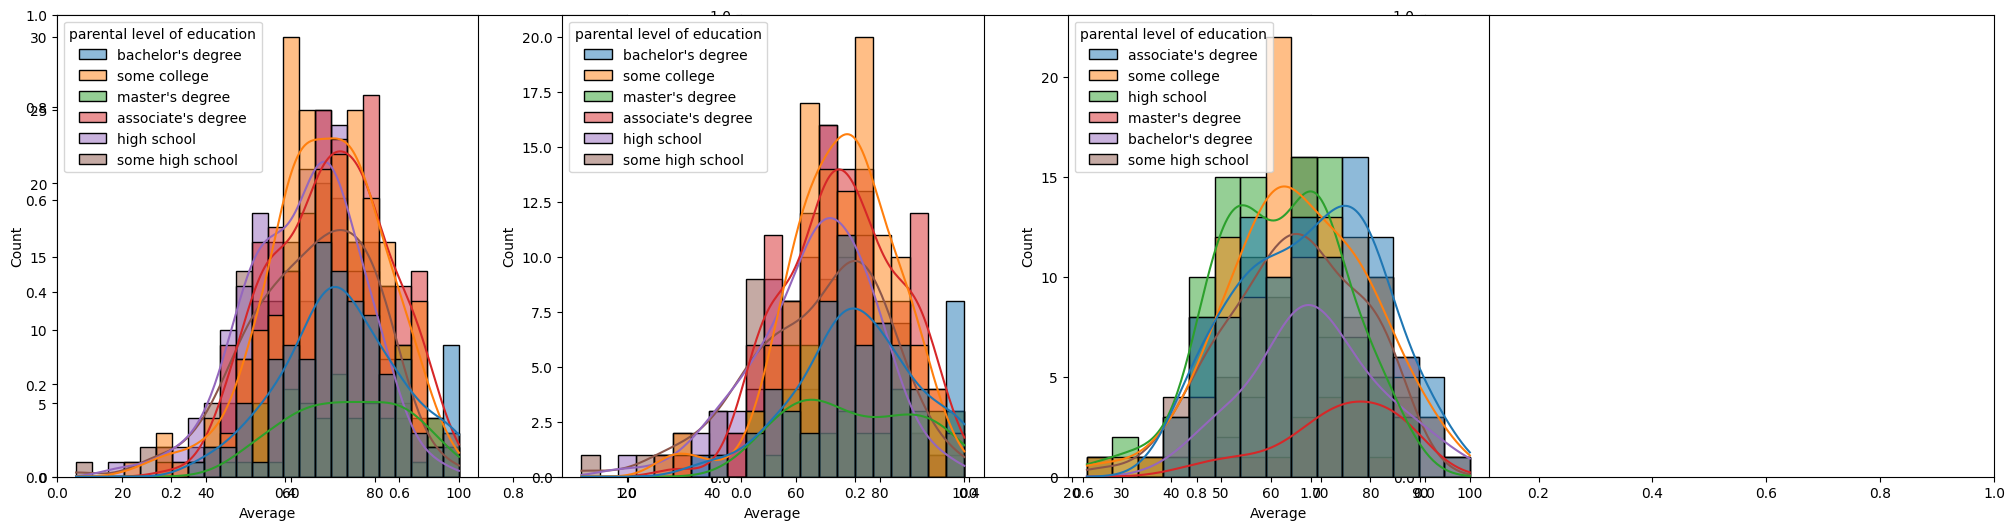

In [22]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='Average',kde=True,hue='parental level of education')
plt.subplot(142)
sns.histplot(data=df[df.gender== 'female'],x='Average',kde=True,hue='parental level of education')
plt.subplot(143)
sns.histplot(data=df[df.gender== 'male'],x='Average',kde=True,hue='parental level of education')
plt.show()

## Insights

* parental level of education don't help in student perform well in exam

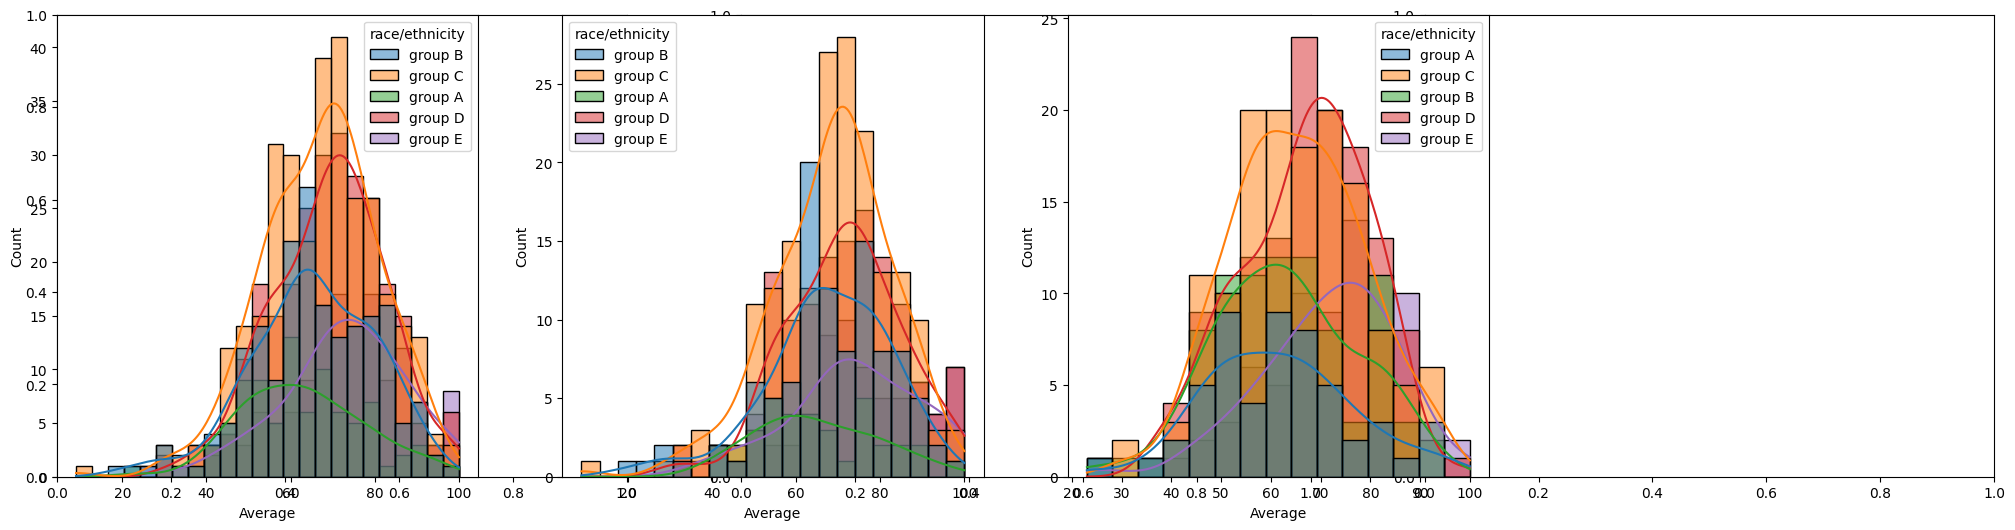

In [23]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='Average',kde=True,hue='race/ethnicity')
plt.subplot(142)
sns.histplot(data=df[df.gender== 'female'],x='Average',kde=True,hue='race/ethnicity')
plt.subplot(143)
sns.histplot(data=df[df.gender== 'male'],x='Average',kde=True,hue='race/ethnicity')
plt.show()

* Group C student perform better 
* Group A student perform worst

## Multivariate analysis using pieplot

(np.float64(-1.25), np.float64(1.25), np.float64(-1.25), np.float64(1.25))

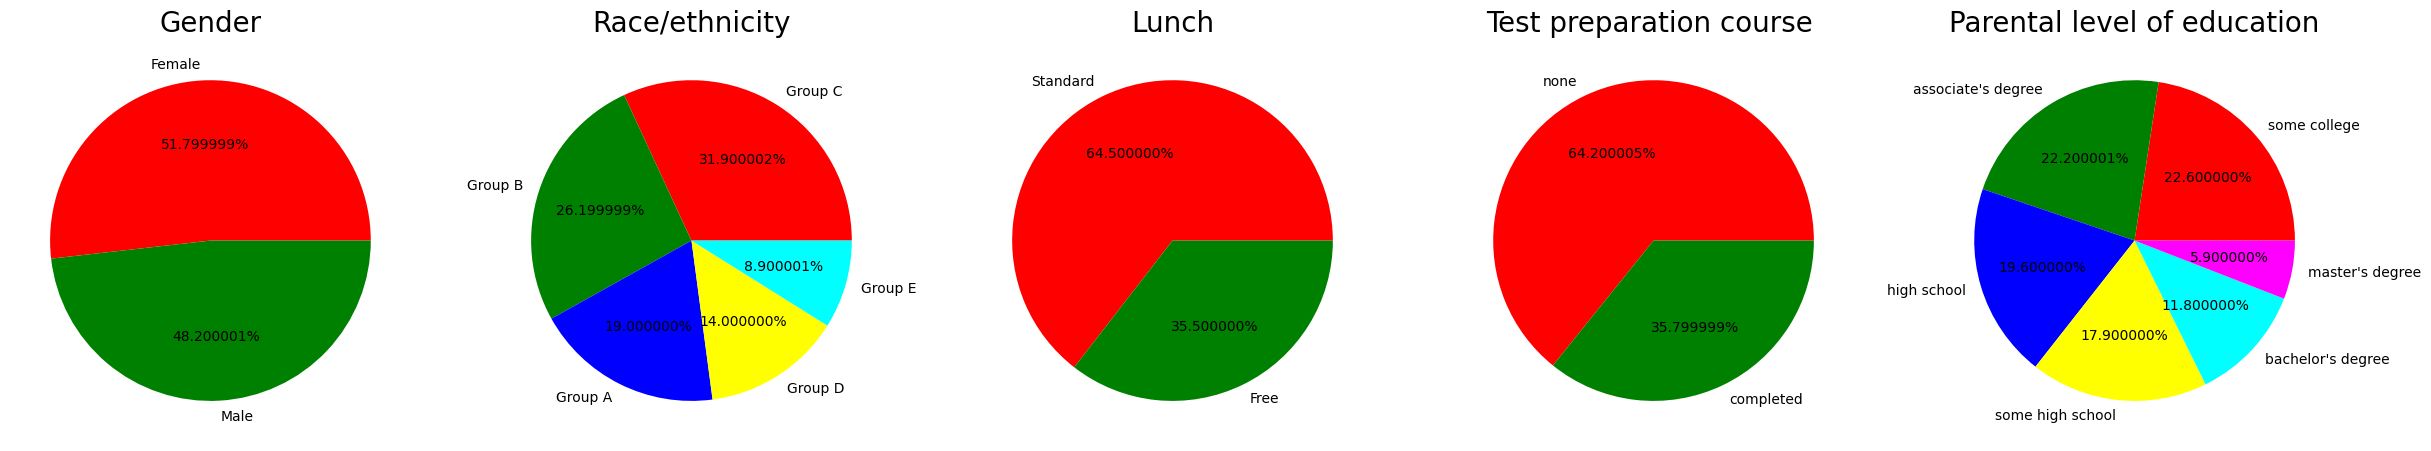

In [24]:
plt.rcParams['figure.figsize']=(30,12)

plt.subplot(1,5,1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']

plt.pie(size, colors = color, labels = labels,autopct='%2f%%')
plt.title('Gender' , fontsize = 20)
plt.axis('off')

plt.subplot(1,5,2)
size = df['race/ethnicity'].value_counts()
labels = 'Group C', 'Group B', 'Group A', 'Group D', 'Group E'
color = ['red','green','blue','yellow','cyan']

plt.pie(size,colors=color, labels=labels,autopct='%2f%%')
plt.title('Race/ethnicity' , fontsize = 20)
plt.axis('off')

plt.subplot(1,5,3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size,colors=color, labels=labels,autopct='%2f%%')
plt.title('Lunch' , fontsize = 20)
plt.axis('off')

plt.subplot(1,5,4)
size = df['test preparation course'].value_counts()
labels = 'none', 'completed'
color = ['red','green']

plt.pie(size,colors=color, labels=labels,autopct='%2f%%')
plt.title('Test preparation course ' , fontsize = 20)
plt.axis('off')

plt.subplot(1,5,5)
size = df['parental level of education'].value_counts()
labels = 'some college', 'associate\'s degree', 'high school', 'some high school', 'bachelor\'s degree', 'master\'s degree'
color = ['red','green','blue','yellow','cyan','magenta']

plt.pie(size,colors=color, labels=labels,autopct='%2f%%')
plt.title('Parental level of education' , fontsize = 20)
plt.axis('off')

## Insights
* Female are 51% and male are 49%
* more student take Standard Lunch
* Most of the student have not taken the test preparation course 
* Most of the students parents are either from some college or associate's degree

## Feature Wise Visulization

## Race/Ethncity Column

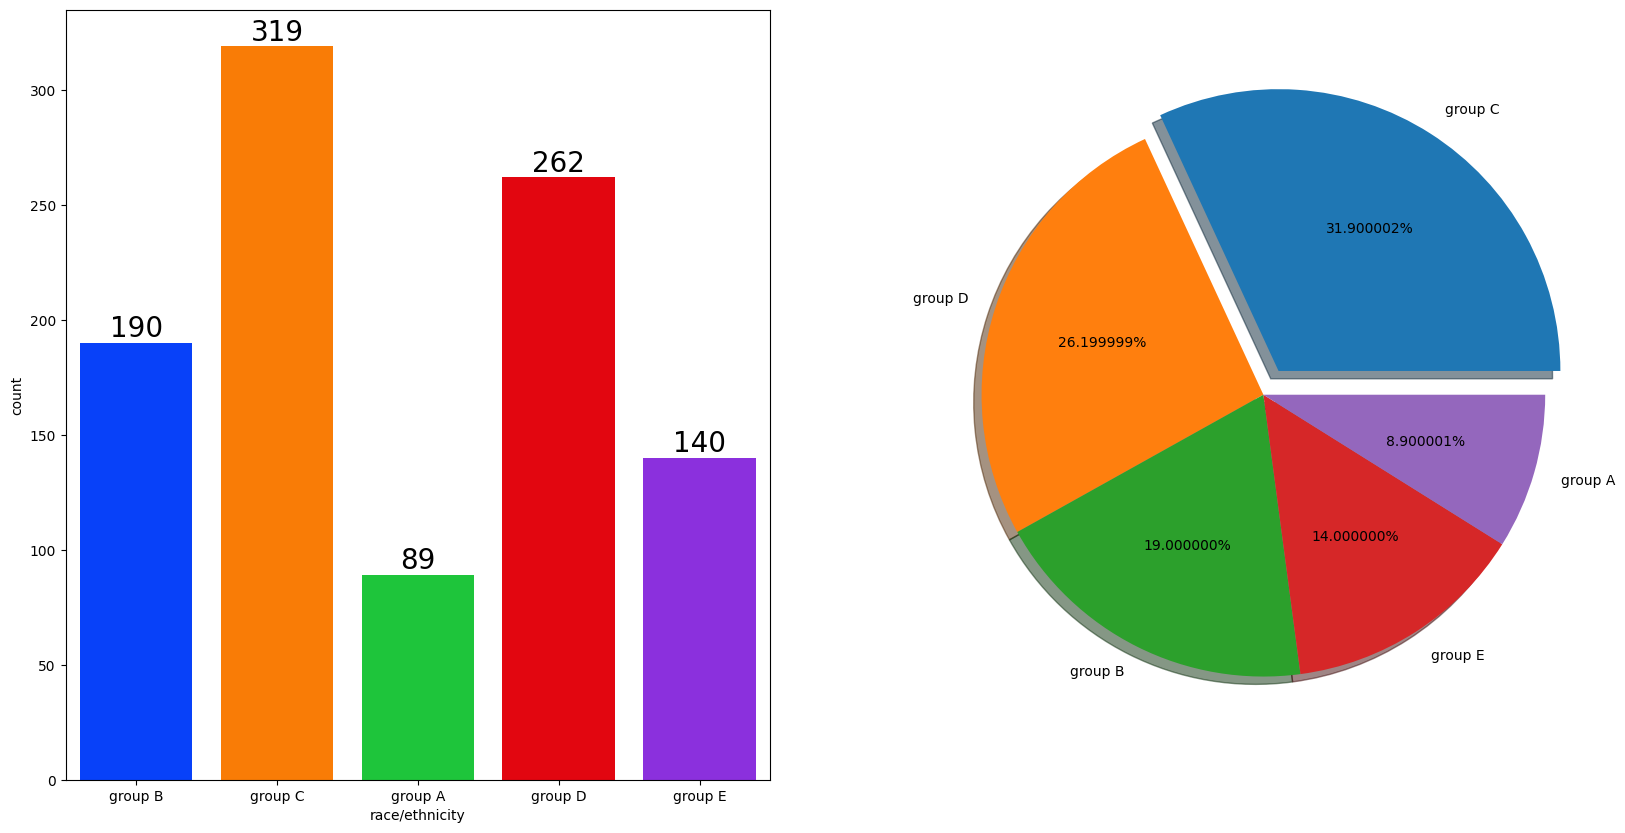

In [25]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race/ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation = 0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

plt.pie(x=df['race/ethnicity'].value_counts(),labels=df['race/ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%2f%%',shadow=True)
plt.show()

* most of the student belong to Group C / Group D

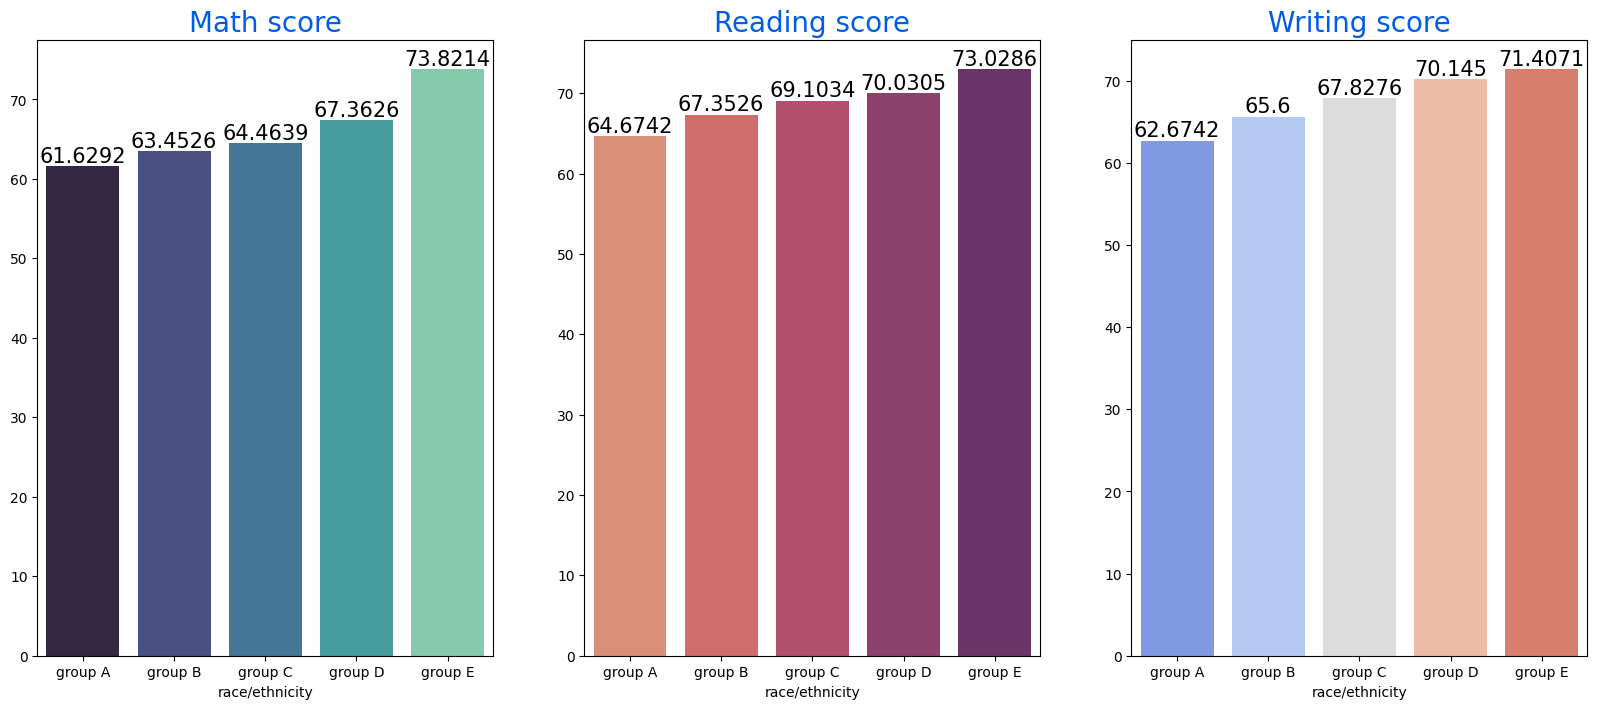

In [26]:
Group_data2=df.groupby('race/ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math score'].mean().index,y=Group_data2['math score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading score'].mean().index,y=Group_data2['reading score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing score'].mean().index,y=Group_data2['writing score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

#### Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower avg in all course subjects

## Test Preparation Course Column

<Axes: xlabel='lunch', ylabel='writing score'>

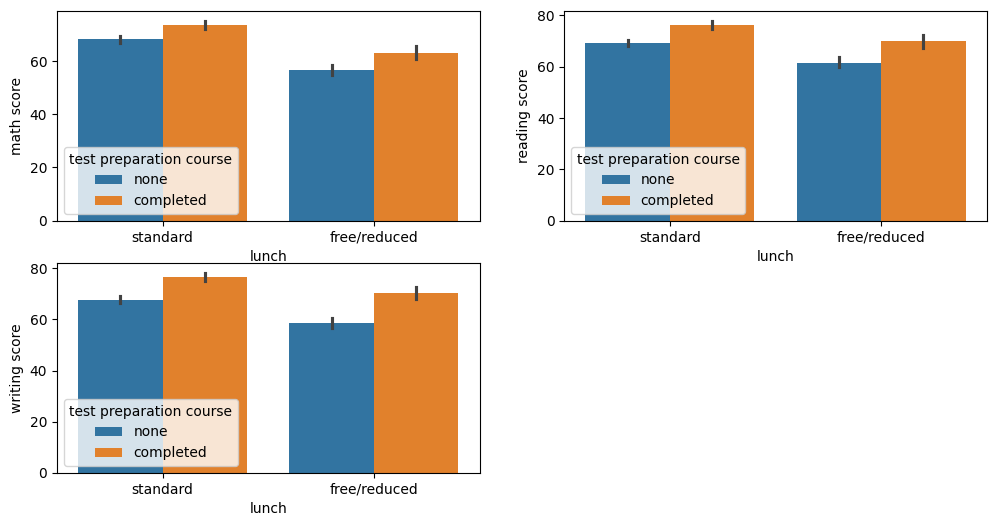

In [27]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math score'], hue=df['test preparation course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading score'], hue=df['test preparation course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing score'], hue=df['test preparation course'])

#### Insights  
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

## CHECKING OUTLIERS

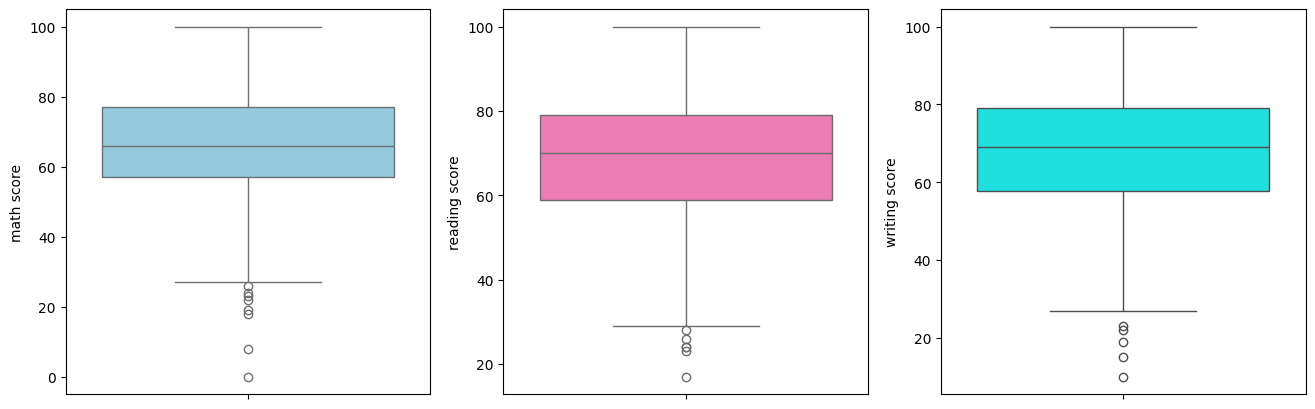

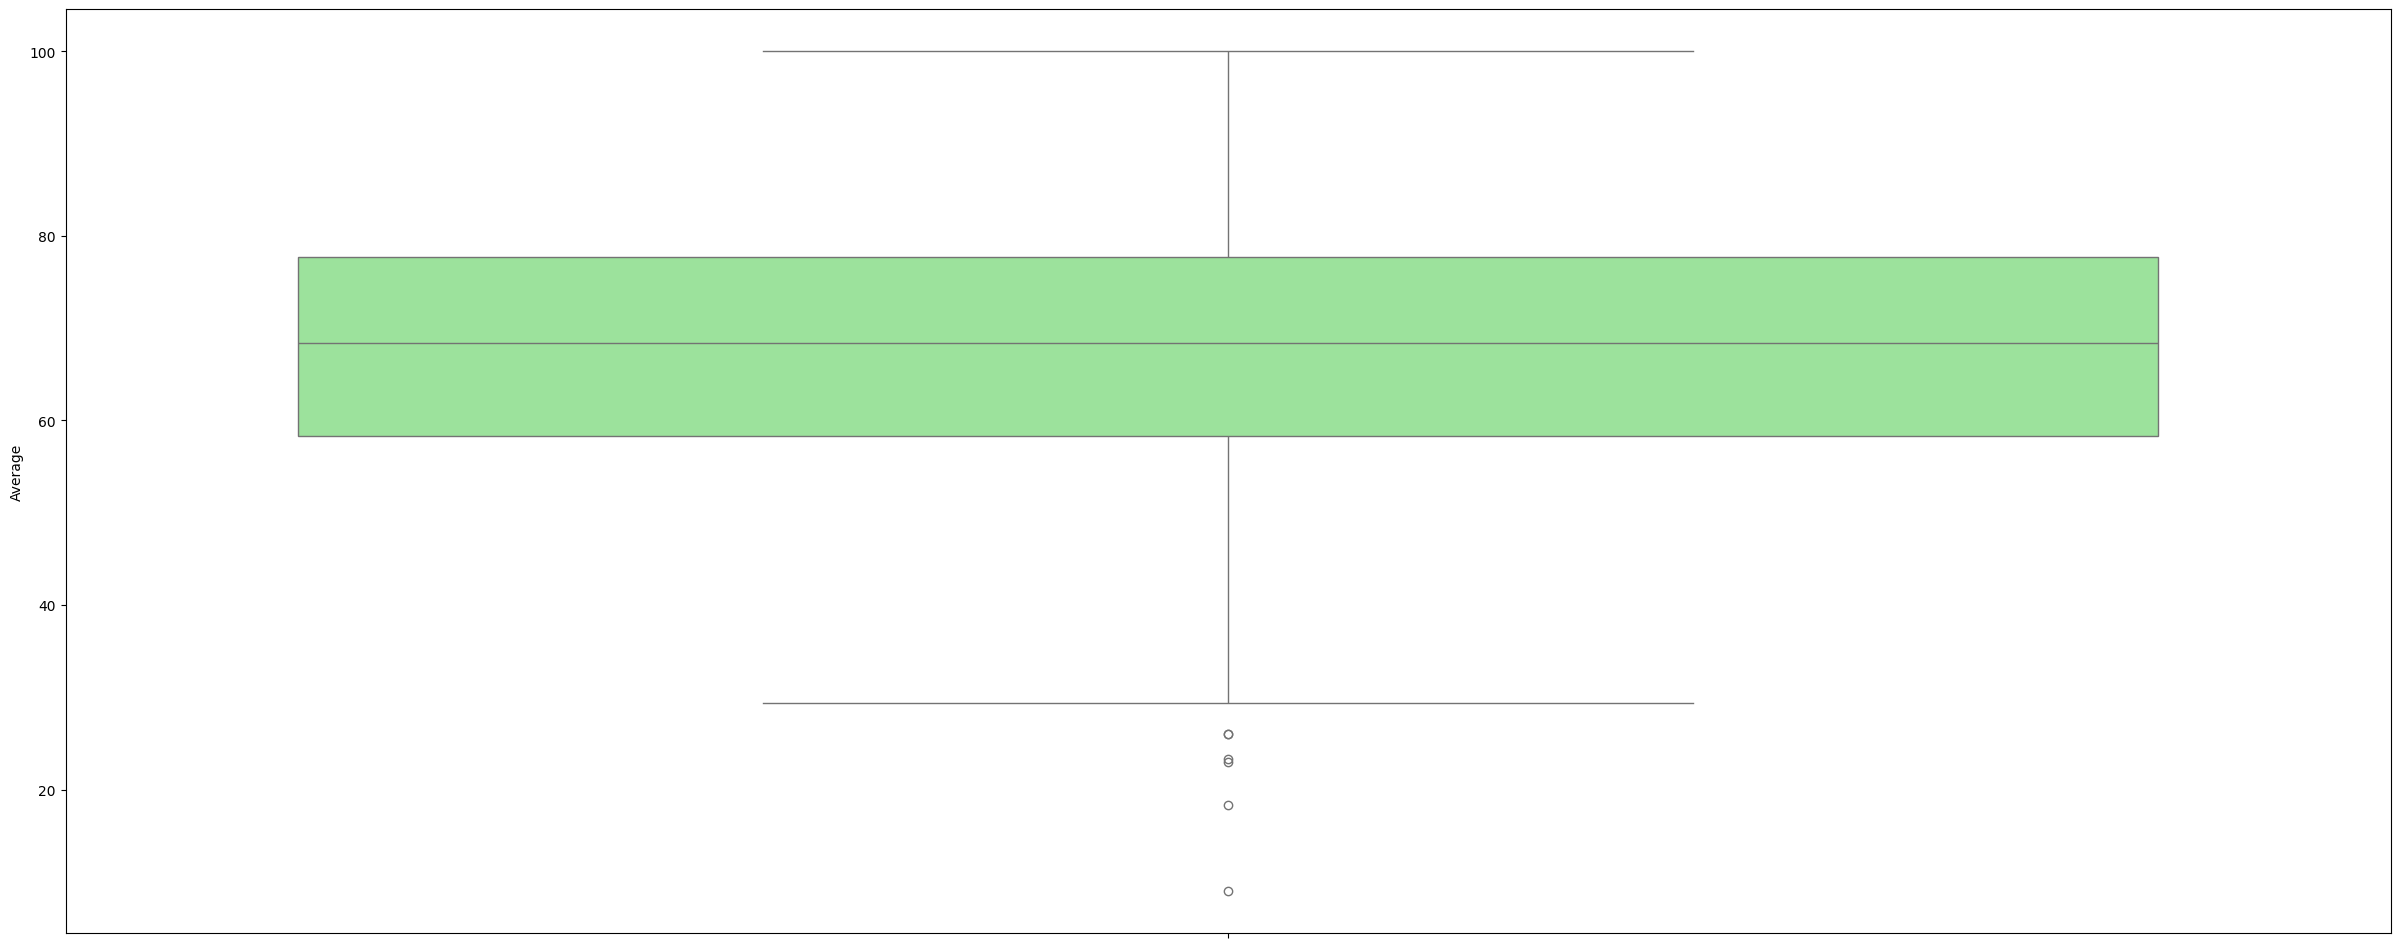

In [31]:
plt.subplots(1,3,figsize=(16,5))
plt.subplot(131)
sns.boxplot(df['math score'],color='Skyblue')
plt.subplot(132)
sns.boxplot(df['reading score'],color='hotpink')
plt.subplot(133)
sns.boxplot(df['writing score'],color='cyan')
plt.show(134)
sns.boxplot(df['Average'],color='lightgreen')
plt.show()

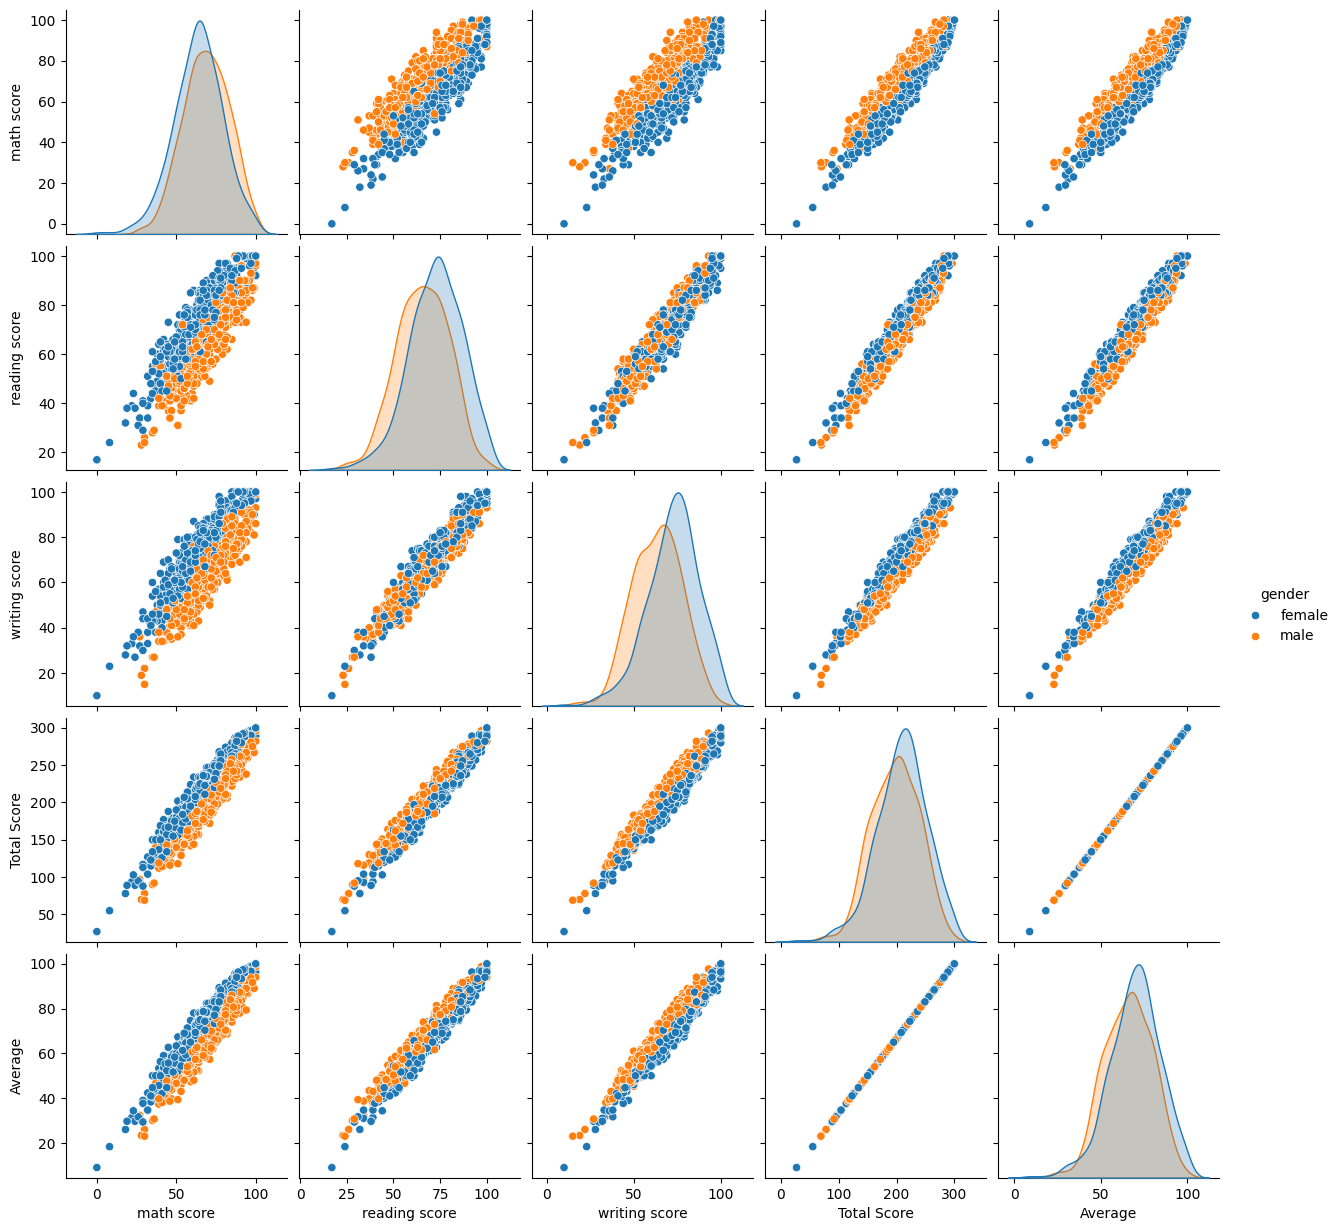

In [32]:
sns.pairplot(df,hue='gender')
plt.show()

#### Insights
- From the above plot it is clear that all the scores increase linearly with each other.

### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.